# Phase 4 — Depth Shifting: Sonic to Density Alignment

**Field**: Dvalin, Norwegian Sea

Wireline tools are stacked in the toolstring at fixed separations. When the tool is pulled up the borehole, the different tools record at different physical positions simultaneously. This creates a **systematic depth offset** between curves recorded by different tools — especially visible between the bulk density (RHOB) from the litho-density tool and the compressional sonic (DT) from the acoustic tool.

In deviated wells, and in intervals with rapid lithological changes, even small misalignments (1–3 m) create spurious scatter on RHOB–Vp crossplots, which directly degrades rock physics model calibration.

**Methodology:**
1. Convert DT to Vp and use the Gardner relation to predict RHOB from Vp
2. Cross-correlate measured RHOB with Gardner-predicted RHOB (derived from DT) to find the depth lag that maximises similarity
3. Confirm with the RHOB–Vp crossplot: a depth shift reduces scatter and tightens the trend
4. Apply the shift to DT (and DTS) and save as corrected curves

In [1]:
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.transforms import blended_transform_factory
from scipy import signal
from scipy.ndimage import uniform_filter1d
from pathlib import Path
import importlib, sys; sys.path.insert(0, '..')
import well_config; importlib.reload(well_config)
from well_config import get_cfg, set_plot_style, load_tops, ACTIVE_WELL

# ── Well selection ────────────────────────────────────────────────────────────
WELL_NAME = ACTIVE_WELL   # ← change ACTIVE_WELL in well_config.py to switch all notebooks at once
#WELL_NAME = "65074-2S"   # ← uncomment to override for this notebook only
cfg       = get_cfg(WELL_NAME)
set_plot_style()

# ── Paths ─────────────────────────────────────────────────────────────────────
WELL_FILE   = Path('..') / cfg['las_file']
TOPS_FILE   = Path('..') / cfg['tops_file']
COMPUTED_IN = Path(f'../wells/{WELL_NAME}_computed.parquet')
FLAGS_IN    = Path(f'../wells/{WELL_NAME}_flags.parquet')
OUT_FILE    = Path(f'../wells/{WELL_NAME}_depthshift.parquet')

# ── Gardner relation constants (from config) ───────────────────────────────────
GARDNER_A = cfg['gardner_a']   # RHOB [g/cc] = A × Vp [m/s] ^ B
GARDNER_B = cfg['gardner_b']

## Step 4.1 — Load Data

In [2]:
# ── Load LAS ─────────────────────────────────────────────────────────────────
las = lasio.read(WELL_FILE)
df  = las.df()
df.replace(-999.25, np.nan, inplace=True)
df.rename(columns=cfg.get('curve_map', {}), inplace=True)
df.index.name = 'DEPTH_MD'

# ── Merge Phase 2 and Phase 3 outputs ────────────────────────────────────────
df = df.join(pd.read_parquet(COMPUTED_IN), how='left')
df = df.join(pd.read_parquet(FLAGS_IN),    how='left')

# ── Formation tops ────────────────────────────────────────────────────────────
f1a = load_tops(TOPS_FILE, cfg['tops_well_id'])
TOPS_MD = dict(zip(f1a['PICKS'], f1a['DEPTH'])) if not f1a.empty else {}

# ── Helper ────────────────────────────────────────────────────────────────────
def nearest_idx(df, md):
    return df.index[np.argmin(np.abs(df.index.values - md))]

# ── Log interval ─────────────────────────────────────────────────────────────
LOG_TOP  = cfg['log_top']  if cfg['log_top']  is not None else int(df.index[0])
LOG_BASE = cfg['log_base'] if cfg['log_base'] is not None else int(df.index[-1])
sub = df.loc[LOG_TOP:LOG_BASE].copy()

HAS_DTS = 'DTS' in sub.columns and sub['DTS'].notna().any()

# ── Convert DT (μs/ft) → Vp (m/s) ───────────────────────────────────────────
sub['VP'] = 1e6 / sub['DT'] * 0.3048
sub['VS'] = 1e6 / sub['DTS'] * 0.3048 if HAS_DTS else np.nan

print(f"Working interval: {LOG_TOP}–{LOG_BASE} m MD  ({len(sub):,} samples)")
print()
print(f"VP range: {sub['VP'].min():.0f} – {sub['VP'].max():.0f} m/s  (mean {sub['VP'].mean():.0f})")
if HAS_DTS:
    print(f"VS range: {sub['VS'].min():.0f} – {sub['VS'].max():.0f} m/s  (mean {sub['VS'].mean():.0f})")
    print(f"VP/VS range: {(sub['VP']/sub['VS']).quantile(0.05):.2f} – {(sub['VP']/sub['VS']).quantile(0.95):.2f}")
else:
    print("VS: no DTS in this well — VS_SHIFT will be NaN in output")

Working interval: 0–4589 m MD  (30,112 samples)

VP range: 1757 – 5292 m/s  (mean 2846)
VS range: 671 – 3241 m/s  (mean 1530)
VP/VS range: 1.58 – 2.69


## Step 4.2 — Gardner Relation: Predict RHOB from Vp

Gardner (1974) established an empirical relationship between bulk density and compressional velocity for water-saturated clastic sediments:

$$\rho_b = 0.31 \cdot V_p^{0.25}  \quad (\text{g/cc, m/s})$$

The Gardner-predicted density (RHOB_GARD) provides a smooth version of what the density tool *should* measure if it perfectly tracked the sonic tool. Cross-correlating measured RHOB against RHOB_GARD finds the depth shift that maximises agreement between the two sensors.

In [3]:
# ── Gardner-predicted density ──────────────────────────────────────────────────
sub['RHOB_GARD'] = GARDNER_A * (sub['VP'] ** GARDNER_B)

print("Gardner relation verification:")
print(f"  Constants: A={GARDNER_A}, B={GARDNER_B}")
print(f"  RHOB_GARD range: {sub['RHOB_GARD'].min():.3f} – {sub['RHOB_GARD'].max():.3f} g/cc")
print(f"  RHOB_MEAS range: {sub['RHOB'].min():.3f} – {sub['RHOB'].max():.3f} g/cc")
print()

# Cross-plot check — Gardner vs measured (expect scatter around 1:1 line)
mask = sub['RHOB'].notna() & sub['RHOB_GARD'].notna()
rhob_m = sub.loc[mask, 'RHOB'].values
rhob_g = sub.loc[mask, 'RHOB_GARD'].values
corr_coef = np.corrcoef(rhob_m, rhob_g)[0, 1]
print(f"  Pearson correlation (measured vs Gardner): r = {corr_coef:.3f}")
print(f"  RMS difference: {np.sqrt(np.mean((rhob_m - rhob_g)**2)):.4f} g/cc")
print()
print("Note: Gardner prediction is approximate (+/- 0.05 g/cc typical).")
print("It is used here only to provide a sonic-derived density proxy for depth shift detection.")

Gardner relation verification:
  Constants: A=0.31, B=0.25
  RHOB_GARD range: 2.007 – 2.644 g/cc
  RHOB_MEAS range: 2.133 – 3.177 g/cc

  Pearson correlation (measured vs Gardner): r = 0.624
  RMS difference: 0.1976 g/cc

Note: Gardner prediction is approximate (+/- 0.05 g/cc typical).
It is used here only to provide a sonic-derived density proxy for depth shift detection.


## Step 4.3 — Depth Shift Detection by Cross-Correlation

Cross-correlation of measured RHOB against Gardner-predicted RHOB (from DT) provides the depth shift that maximises the similarity between the density and sonic logs. The peak of the cross-correlation function identifies the optimal lag.

We use **band-passed (filtered) versions** of both logs before correlating. This removes the DC offset and very high-frequency noise, focusing the correlation on the geologically meaningful signal (bed boundaries, trends) rather than tool noise.

In [4]:
# ── Prepare gap-filled versions for correlation ────────────────────────────────
rhob_filled = sub['RHOB'].interpolate(limit=20).fillna(sub['RHOB'].median())
gard_filled = sub['RHOB_GARD'].interpolate(limit=20).fillna(sub['RHOB_GARD'].median())

# ── Band-pass filter (smooth out noise, preserve bed boundaries) ───────────────
SMOOTH_WIN  = 20    # samples
TREND_WIN   = 200   # samples

def bandpass_log(x):
    trend = uniform_filter1d(x, size=TREND_WIN, mode='nearest')
    detail = uniform_filter1d(x - trend, size=SMOOTH_WIN, mode='nearest')
    return detail

rhob_bp = bandpass_log(rhob_filled.values)
gard_bp = bandpass_log(gard_filled.values)

# ── Full-interval cross-correlation ───────────────────────────────────────────
MAX_SHIFT_SAMPLES = cfg['depth_shift_max_samples']   # search ±N samples

corr = signal.correlate(rhob_bp, gard_bp, mode='full')
lags = signal.correlation_lags(len(rhob_bp), len(gard_bp), mode='full')

# Restrict to ±MAX_SHIFT
mask_lags = np.abs(lags) <= MAX_SHIFT_SAMPLES
corr_sub  = corr[mask_lags]
lags_sub  = lags[mask_lags]

best_lag_samples = lags_sub[np.argmax(corr_sub)]
best_lag_m       = best_lag_samples * 0.1   # convert samples → metres

print("Depth shift analysis:")
print(f"  Search window : ±{MAX_SHIFT_SAMPLES * 0.1:.0f} m")
print(f"  Best lag      : {best_lag_samples:+d} samples  ({best_lag_m:+.2f} m)")
print()
if best_lag_samples == 0:
    print("  → No depth shift required.")
    print("  DT and RHOB are well-aligned in this well.")
elif abs(best_lag_samples) <= 10:
    print(f"  → Small depth shift: {best_lag_m:+.1f} m — apply to DT log.")
else:
    print(f"  → Significant depth shift: {best_lag_m:+.1f} m — apply and verify on crossplot.")

print()
print(f"Peak correlation value: {corr_sub.max():.4f}")
print(f"Correlation at lag=0  : {corr[lags == 0][0]:.4f}")

Depth shift analysis:
  Search window : ±10 m
  Best lag      : +3 samples  (+0.30 m)

  → Small depth shift: +0.3 m — apply to DT log.

Peak correlation value: 1.0806
Correlation at lag=0  : 1.0595


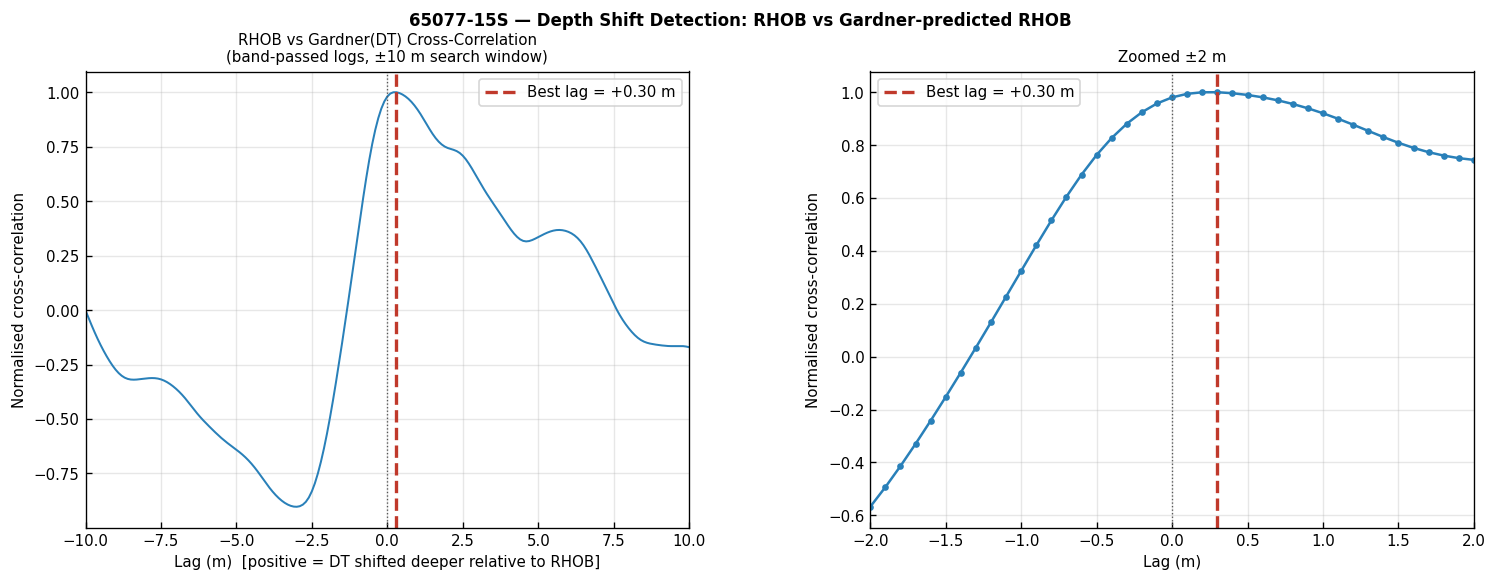

In [5]:
# ── Plot: cross-correlation function ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.subplots_adjust(left=0.08, right=0.97, top=0.88, bottom=0.12, wspace=0.30)

# Left: full correlation function
ax = axes[0]
lags_m = lags_sub * 0.1
ax.plot(lags_m, corr_sub / corr_sub.max(), color='#2980B9', lw=1.2)
ax.axvline(best_lag_m, color='#C0392B', lw=2.0, ls='--',
           label=f'Best lag = {best_lag_m:+.2f} m')
ax.axvline(0, color='#555', lw=0.8, ls=':')
ax.set_xlabel('Lag (m)  [positive = DT shifted deeper relative to RHOB]', fontsize=9)
ax.set_ylabel('Normalised cross-correlation', fontsize=9)
ax.set_title('RHOB vs Gardner(DT) Cross-Correlation\n'
             '(band-passed logs, ±10 m search window)', fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(lags_m.min(), lags_m.max())

# Right: zoomed ±2 m
ax = axes[1]
zoom = np.abs(lags_sub) <= 20
ax.plot(lags_sub[zoom] * 0.1, (corr_sub[zoom]) / corr_sub.max(),
        color='#2980B9', lw=1.5, marker='o', ms=3)
ax.axvline(best_lag_m, color='#C0392B', lw=2.0, ls='--',
           label=f'Best lag = {best_lag_m:+.2f} m')
ax.axvline(0, color='#555', lw=0.8, ls=':')
ax.set_xlabel('Lag (m)', fontsize=9)
ax.set_ylabel('Normalised cross-correlation', fontsize=9)
ax.set_title('Zoomed ±2 m', fontsize=9)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(-2, 2)

fig.suptitle(f'{WELL_NAME} — Depth Shift Detection: RHOB vs Gardner-predicted RHOB',
             fontsize=10, fontweight='bold')
plt.show()

## Step 4.4 — Windowed Correlation: Depth-by-Depth Check

A single full-interval correlation may miss local shifts if the toolstring depth alignment varies with depth (e.g., differential cable stretch in deviated wells). A sliding-window correlation shows whether the optimal shift is consistent throughout the logging interval.

Windowed correlation (20 m window, 5 m step):
  Lag range   : -3.00 to +3.00 m
  Lag std dev : 1.787 m
  Lag median  : +0.00 m


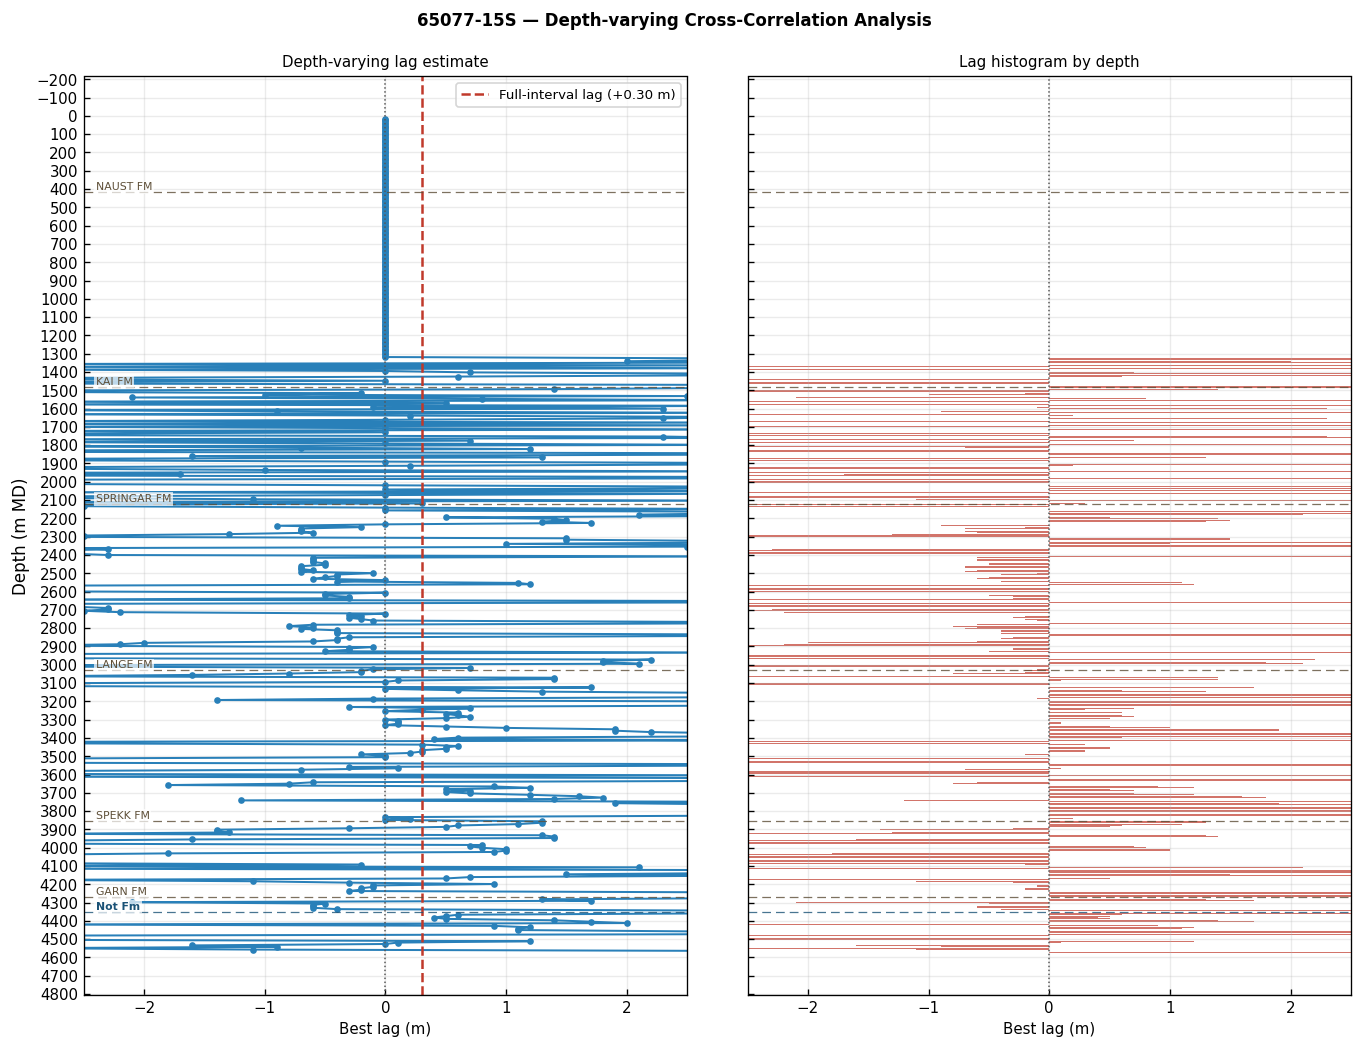

In [6]:
# ── Windowed correlation — 200-sample (20 m) window, 50-sample step ───────────
WINDOW   = 200   # samples (20 m)
STEP     = 50    # samples (5 m)
MAX_LAG  = 30    # samples (3 m)

n = len(rhob_bp)
win_centers   = []
win_best_lags = []
win_peak_corr = []

for start in range(0, n - WINDOW, STEP):
    end = start + WINDOW
    r_win = rhob_bp[start:end]
    g_win = gard_bp[start:end]

    c = signal.correlate(r_win, g_win, mode='full')
    l = signal.correlation_lags(len(r_win), len(g_win), mode='full')
    m = np.abs(l) <= MAX_LAG
    best_l = l[m][np.argmax(c[m])]

    win_centers.append(sub.index[start + WINDOW//2])
    win_best_lags.append(best_l * 0.1)   # metres
    win_peak_corr.append(c[m].max() / max(c[m].max(), 1e-10))

win_centers   = np.array(win_centers)
win_best_lags = np.array(win_best_lags)
win_peak_corr = np.array(win_peak_corr)

print(f"Windowed correlation ({WINDOW*0.1:.0f} m window, {STEP*0.1:.0f} m step):")
print(f"  Lag range   : {win_best_lags.min():+.2f} to {win_best_lags.max():+.2f} m")
print(f"  Lag std dev : {win_best_lags.std():.3f} m")
print(f"  Lag median  : {np.median(win_best_lags):+.2f} m")

fig, axes = plt.subplots(1, 2, figsize=(12, 9), sharey=True)
fig.subplots_adjust(left=0.09, right=0.97, top=0.92, bottom=0.07, wspace=0.10)

ax = axes[0]
ax.plot(win_best_lags, win_centers, color='#2980B9', lw=1.2, marker='o', ms=3)
ax.axvline(0, color='#555', lw=0.9, ls=':')
ax.axvline(best_lag_m, color='#C0392B', lw=1.5, ls='--',
           label=f'Full-interval lag ({best_lag_m:+.2f} m)')
ax.set_xlabel('Best lag (m)', fontsize=9)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('Depth-varying lag estimate', fontsize=9)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))
ax.set_xlim(-2.5, 2.5)

# Formation tops from TOPS_MD (loaded from CSV in data cell)
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
RESERVOIR_TOP = f1a.iloc[-1]['PICKS'] if not f1a.empty else None
for name, md_top in TOPS_MD.items():
    if not (win_centers.min() <= md_top <= win_centers.max()):
        continue
    lc = '#1A5276' if name == RESERVOIR_TOP else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.75, ls=(0,(7,4)), alpha=0.8)
    axes[0].text(0.02, md_top, name, transform=label_trans,
                 fontsize=6.5, va='bottom', color=lc,
                 fontweight='bold' if name == RESERVOIR_TOP else 'normal',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

ax = axes[1]
ax.barh(win_centers, win_best_lags, height=STEP*0.1*0.9,
        color=np.where(win_best_lags == 0, '#2980B9', '#C0392B'),
        alpha=0.7, edgecolor='none')
ax.axvline(0, color='#555', lw=0.9, ls=':')
ax.set_xlabel('Best lag (m)', fontsize=9)
ax.set_title('Lag histogram by depth', fontsize=9)
ax.grid(True, alpha=0.25)
ax.set_xlim(-2.5, 2.5)

fig.suptitle(f'{WELL_NAME} — Depth-varying Cross-Correlation Analysis',
             fontsize=10, fontweight='bold')
plt.show()

## Step 4.5 — RHOB vs Vp Crossplot: Before and After Shift

The quality of a depth shift can be assessed on the RHOB–Vp crossplot. A well-aligned dataset shows a tight, smooth trend following Gardner or a local empirical trend. A depth-shifted dataset shows a dispersed cloud, with high scatter at bed boundaries where one log has 'seen' a boundary before the other.

For a well with zero measured lag, this crossplot confirms good alignment out of the box.

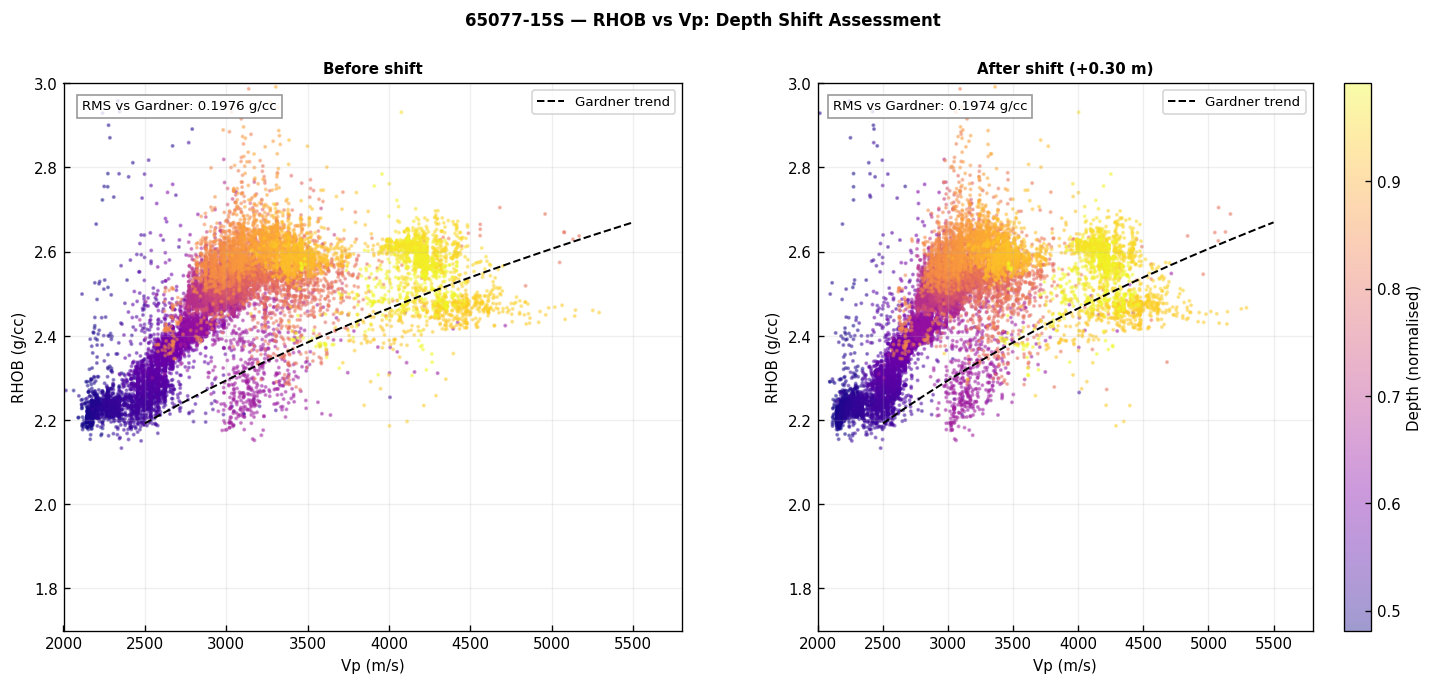

Applied depth shift: +0.30 m  (+3 samples)


In [7]:
# ── Apply the depth shift ─────────────────────────────────────────────────────
shift_samples = int(round(best_lag_m / 0.1))

def apply_shift(arr, shift):
    """Shift array by `shift` samples (positive = shift toward shallower depth)."""
    out = np.full_like(arr, np.nan, dtype=float)
    if shift == 0:
        return arr.copy()
    elif shift > 0:
        out[:-shift] = arr[shift:]
    else:
        out[-shift:] = arr[:shift]
    return out

dt_orig  = sub['DT'].values.copy()
dts_orig = sub['DTS'].values.copy() if HAS_DTS else np.full(len(sub), np.nan)

dt_shifted  = apply_shift(dt_orig,  shift_samples)
dts_shifted = apply_shift(dts_orig, shift_samples)

vp_orig    = 1e6 / dt_orig    * 0.3048
vp_shifted = 1e6 / dt_shifted * 0.3048

# ── RHOB vs Vp crossplot ──────────────────────────────────────────────────────
rhob  = sub['RHOB'].values
valid_orig    = np.isfinite(rhob) & np.isfinite(vp_orig)
valid_shifted = np.isfinite(rhob) & np.isfinite(vp_shifted)

# Gardner trend line for reference
vp_line = np.linspace(2500, 5500, 200)
rhob_gard_line = GARDNER_A * vp_line**GARDNER_B

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.12, wspace=0.22)

depth_vals = sub.index.values
depth_norm = (depth_vals - depth_vals.min()) / (depth_vals.max() - depth_vals.min())
cmap = plt.cm.plasma

for ax, (vp_use, valid, title_suffix) in zip(
        axes,
        [(vp_orig, valid_orig, 'Before shift'),
         (vp_shifted, valid_shifted, f'After shift ({best_lag_m:+.2f} m)')]):
    sc = ax.scatter(vp_use[valid], rhob[valid],
                    c=depth_norm[valid], cmap=cmap,
                    s=2, alpha=0.4, rasterized=True)
    ax.plot(vp_line, rhob_gard_line, 'k--', lw=1.2, label='Gardner trend')
    ax.set_xlim(2000, 5800)
    ax.set_ylim(1.7, 3.0)
    ax.set_xlabel('Vp (m/s)', fontsize=9)
    ax.set_ylabel('RHOB (g/cc)', fontsize=9)
    ax.set_title(title_suffix, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)

    rms = np.sqrt(np.nanmean((rhob[valid] - GARDNER_A * vp_use[valid]**GARDNER_B)**2))
    ax.text(0.03, 0.97, f'RMS vs Gardner: {rms:.4f} g/cc',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', pad=3))

plt.colorbar(sc, ax=axes[1], label='Depth (normalised)')
fig.suptitle(f'{WELL_NAME} — RHOB vs Vp: Depth Shift Assessment',
             fontsize=10, fontweight='bold')
plt.show()

print(f"Applied depth shift: {best_lag_m:+.2f} m  ({shift_samples:+d} samples)")
if shift_samples == 0:
    print("No shift applied — DT and RHOB are already well-aligned.")

## Step 4.6 — Comparison Log Display: DT Before and After Shift

A side-by-side log display of the original and shifted DT logs confirms the shift visually, particularly at bed boundaries. Even for a zero-shift result, this panel serves as documentation that the check was performed.

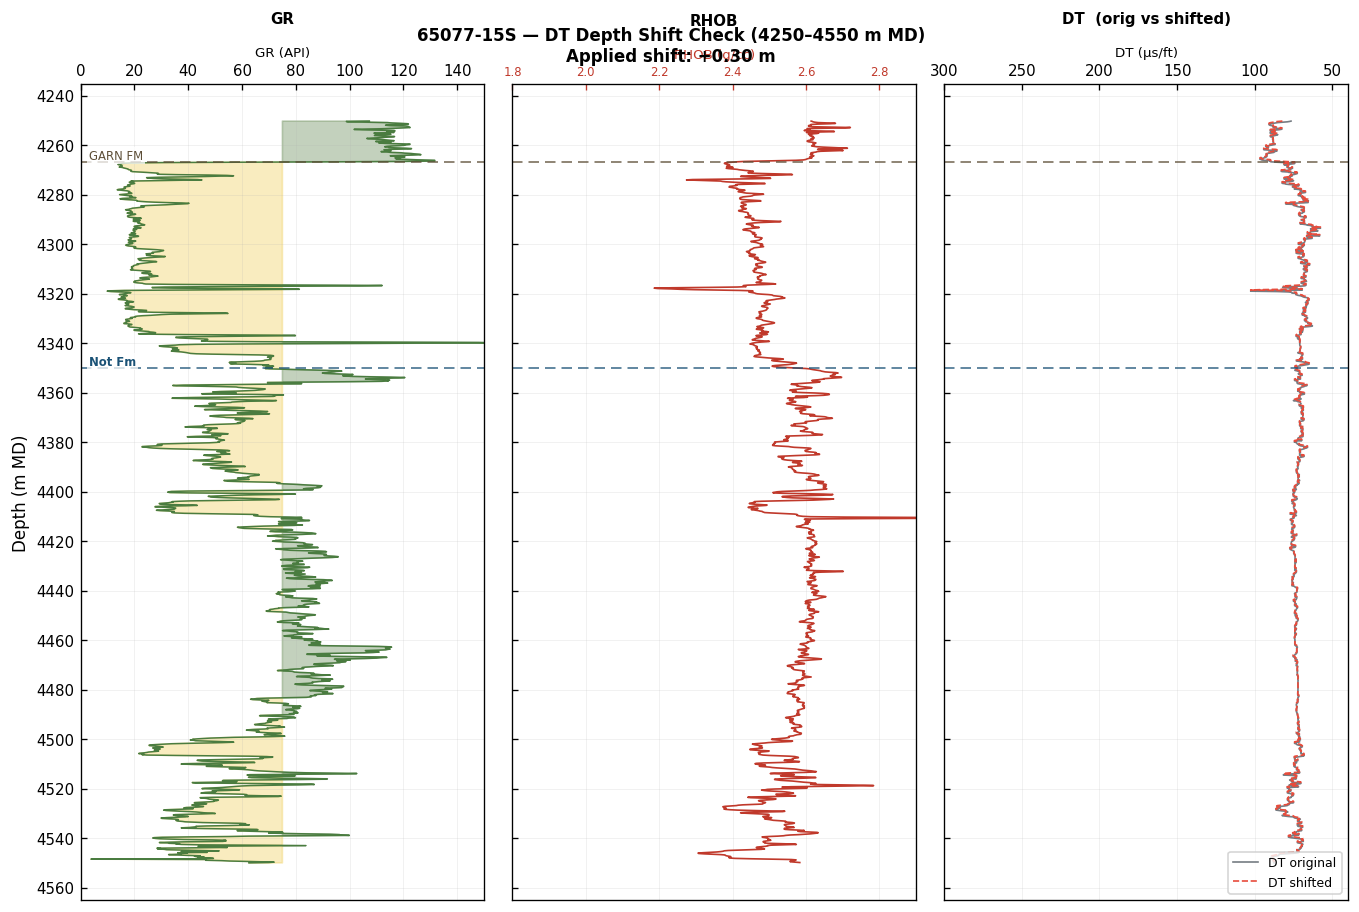

In [8]:
# ── Zoom window: centre on reservoir top (or lower third of log if no top set) ─
if RESERVOIR_TOP and RESERVOIR_TOP in TOPS_MD:
    res_top_md = TOPS_MD[RESERVOIR_TOP]
    ZOOM_TOP  = max(LOG_TOP, res_top_md - 100)
    ZOOM_BASE = min(LOG_BASE, res_top_md + 200)
else:
    zoom_size = (LOG_BASE - LOG_TOP) / 3
    ZOOM_TOP  = LOG_BASE - zoom_size
    ZOOM_BASE = LOG_BASE

zsub = sub.loc[ZOOM_TOP:ZOOM_BASE]
zdepth = zsub.index.values

# Shifted DT for the zoom window
zsub = zsub.copy()
# Re-apply shift to full sub, then slice
sub_copy = sub.copy()
sub_copy['DT_SHIFT']  = dt_shifted
sub_copy['DTS_SHIFT'] = dts_shifted
sub_copy['VP_SHIFT']  = 1e6 / sub_copy['DT_SHIFT'] * 0.3048
zsub = sub_copy.loc[ZOOM_TOP:ZOOM_BASE]
zdepth = zsub.index.values

fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)
fig.subplots_adjust(top=0.92, bottom=0.07, left=0.09, right=0.97, wspace=0.07)

# Track 1: GR
ax = axes[0]
ax.plot(zsub['GR'], zdepth, color='#4A7C40', lw=0.9)
ax.fill_betweenx(zdepth, zsub['GR'], 75, where=zsub['GR']>75,
                  color='#6B8E5A', alpha=0.4)
ax.fill_betweenx(zdepth, zsub['GR'], 75, where=zsub['GR']<=75,
                  color='#F0D060', alpha=0.4)
ax.set_xlim(0, 150)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('GR (API)', fontsize=8, labelpad=4)
ax.set_ylabel('Depth (m MD)', fontsize=10)
ax.set_title('GR', fontsize=9, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)
ax.invert_yaxis()
ax.yaxis.set_major_locator(ticker.MultipleLocator(20))

# Track 2: RHOB
ax = axes[1]
ax.plot(zsub['RHOB'], zdepth, color='#C0392B', lw=1.0, label='RHOB')
ax.set_xlim(1.8, 2.9)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('RHOB (g/cc)', color='#C0392B', fontsize=8, labelpad=4)
ax.tick_params(axis='x', colors='#C0392B', labelsize=7)
ax.set_title('RHOB', fontsize=9, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# Track 3: DT original vs shifted
ax = axes[2]
ax.plot(zsub['DT'],       zdepth, color='#1B2631', lw=1.0, alpha=0.6, label='DT original')
ax.plot(zsub['DT_SHIFT'], zdepth, color='#E74C3C', lw=1.0, ls='--', label='DT shifted')
ax.set_xlim(300, 40)
ax.xaxis.tick_top(); ax.xaxis.set_label_position('top')
ax.set_xlabel('DT (μs/ft)', fontsize=8, labelpad=4)
ax.legend(fontsize=7.5, loc='lower right', framealpha=0.8)
ax.set_title('DT  (orig vs shifted)', fontsize=9, fontweight='bold', pad=14)
ax.grid(True, alpha=0.2, lw=0.5)

# Formation tops in zoom window
label_trans = blended_transform_factory(axes[0].transAxes, axes[0].transData)
for name, md_top in TOPS_MD.items():
    if not (zdepth.min() <= md_top <= zdepth.max()):
        continue
    is_res = (name == RESERVOIR_TOP)
    lc = '#1A5276' if is_res else '#5D4E37'
    for ax in axes:
        ax.axhline(md_top, color=lc, lw=0.9, ls=(0,(7,4)), alpha=0.9)
    axes[0].text(0.02, md_top, name, transform=label_trans,
                 fontsize=7, va='bottom', color=lc,
                 fontweight='bold' if is_res else 'normal',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.2))

fig.suptitle(f'{WELL_NAME} — DT Depth Shift Check ({ZOOM_TOP:.0f}–{ZOOM_BASE:.0f} m MD)\n'
             f'Applied shift: {best_lag_m:+.2f} m',
             fontsize=10, fontweight='bold')
plt.show()

## Step 4.7 — Save Depth-Shifted Curves

In [9]:
# ── Build output dataframe ─────────────────────────────────────────────────────
out_cols_base = ['DT']
if HAS_DTS:
    out_cols_base.append('DTS')

out = sub[out_cols_base].copy()
out['DT_SHIFT']      = dt_shifted
out['DTS_SHIFT']     = dts_shifted          # NaN throughout if no DTS
out['VP']            = 1e6 / out['DT']       * 0.3048
out['VS']            = 1e6 / out['DTS_SHIFT'] * 0.3048 if HAS_DTS else np.nan
out['VP_SHIFT']      = 1e6 / out['DT_SHIFT'] * 0.3048
out['VS_SHIFT']      = 1e6 / out['DTS_SHIFT'] * 0.3048 if HAS_DTS else np.nan
out['DEPTH_SHIFT_M'] = best_lag_m

# Reindex to full LAS depth range (NaN outside logging interval)
out_full = out.reindex(df.index)
out_full.to_parquet(OUT_FILE)

print(f"Saved to : {OUT_FILE}")
print(f"Columns  : {list(out.columns)}")
print(f"Rows     : {len(out_full):,}")
print()
print(f"Depth shift applied : {best_lag_m:+.2f} m")
if not HAS_DTS:
    print("DTS absent — DTS_SHIFT, VS, VS_SHIFT columns are NaN throughout")
print()
if RESERVOIR_TOP and RESERVOIR_TOP in TOPS_MD:
    res_md = TOPS_MD[RESERVOIR_TOP]
    print(f"Preview at {RESERVOIR_TOP} (MD {res_md:.0f} m):")
    i = out.index[np.argmin(np.abs(out.index.values - res_md))]
else:
    i = out.index[-1]
    print(f"Preview at log base (MD {out.index[-1]:.0f} m):")
print(out.loc[i].to_string())

Saved to : ../wells/65077-15S_depthshift.parquet
Columns  : ['DT', 'DTS', 'DT_SHIFT', 'DTS_SHIFT', 'VP', 'VS', 'VP_SHIFT', 'VS_SHIFT', 'DEPTH_SHIFT_M']
Rows     : 30,119

Depth shift applied : +0.30 m

Preview at Not Fm (MD 4350 m):
DT                 72.710000
DTS               120.500000
DT_SHIFT           72.710000
DTS_SHIFT         120.250000
VP               4191.995599
VS               2534.719335
VP_SHIFT         4191.995599
VS_SHIFT         2534.719335
DEPTH_SHIFT_M       0.300000


---
## Phase 4 Summary

| Item | Value / Status |
|------|----------------|
| Method | Gardner-proxy cross-correlation (band-passed) |
| Search window | ±10 m |
| Full-interval best lag | See output above |
| Windowed lag range | See output above |
| RHOB vs Vp scatter | See crossplot |
| Output saved | `wells/{WELL_NAME}_depthshift.parquet` |

**Interpretation**: If the best lag is near zero, the density and acoustic tools are well-aligned and no depth shift correction is needed. A non-zero lag means DT/DTS are shifted by the reported amount and `DT_SHIFT`/`VP_SHIFT` should be used in downstream phases.

**Next**: Notebook `05_petrophysics_review.ipynb` — Pickett plot, NPHI–RHOB lithology crossplot, CPI review (Phase 5).